# 07c · GSE65391 · RNA_array · heatmap of every visit, visits clustered

Reads `modules.rds`, `wgcna_input.rds`, `expression.rds`, `projected_scores.rds` (for the metadata).

**Samples and matrix** as notebook 07b: 972 samples (924 SLE, 48 healthy), hub genes standardised with
the first-visit mean and SD, colours capped at plus or minus2.5.

**Rows are clustered**: Ward's method (`ward.D2`) on Minkowski distance with p = 2, over all 972
samples, tree not cut. The question is descriptive: do samples lie near others with similar disease
activity, near other visits of the same child, or near healthy samples? The annotations show SLEDAI,
stage, nephritis, healthy or SLE, and visit number. The statistical test of within-child against
between-child association is the mixed model of notebook 06b.

**Columns**: genes, ordered by the Ward tree of notebook 07.

## Scale every sample and build the two Ward trees

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize)})
mods <- readRDS(art("GSE65391", "modules.rds"))
w    <- readRDS(art("GSE65391", "wgcna_input.rds"))
x    <- readRDS(art("GSE65391", "expression.rds"))
m    <- readRDS(art("GSE65391", "projected_scores.rds"))$meta
hub  <- unlist(lapply(mods$hubs, head, 10))
gene_module <- mods$colors[hub]
mu <- colMeans(w$datExpr[, hub]); s <- apply(w$datExpr[, hub], 2, sd)
X  <- t((x$E[hub, rownames(m)] - mu) / s); Xc <- pmin(pmax(X, -2.5), 2.5)
hc_genes <- hclust(dist(t(scale(w$datExpr[, hub])), method = "minkowski", p = 2), method = "ward.D2")
hc_samples <- hclust(dist(X, method = "minkowski", p = 2), method = "ward.D2")
dim(X)

[1] 972 140

**Explanation**
- `library(ComplexHeatmap)` draws heatmaps with dendrograms and annotation strips (Gu Z, Eils R, Schlesner M.
  Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics*
  2016;32:2847-2849). `library(circlize)` provides `colorRamp2()`, which maps numbers to colours (Gu Z, Gu L,
  Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics*
  2014;30:2811-2812).
- `X` and `Xc` as in notebook 07b: all 972 samples, each hub gene standardised with its first-visit mean
  and SD, colours capped at -2.5 and 2.5.
- `hc_genes`: the Ward tree of the genes from notebook 07.
- `hc_samples`: a Ward tree of all 972 samples (Minkowski p = 2, `ward.D2`, as in notebook 07).
- `dim(X)` prints 972 samples by 140 genes.

## Draw the heatmap

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



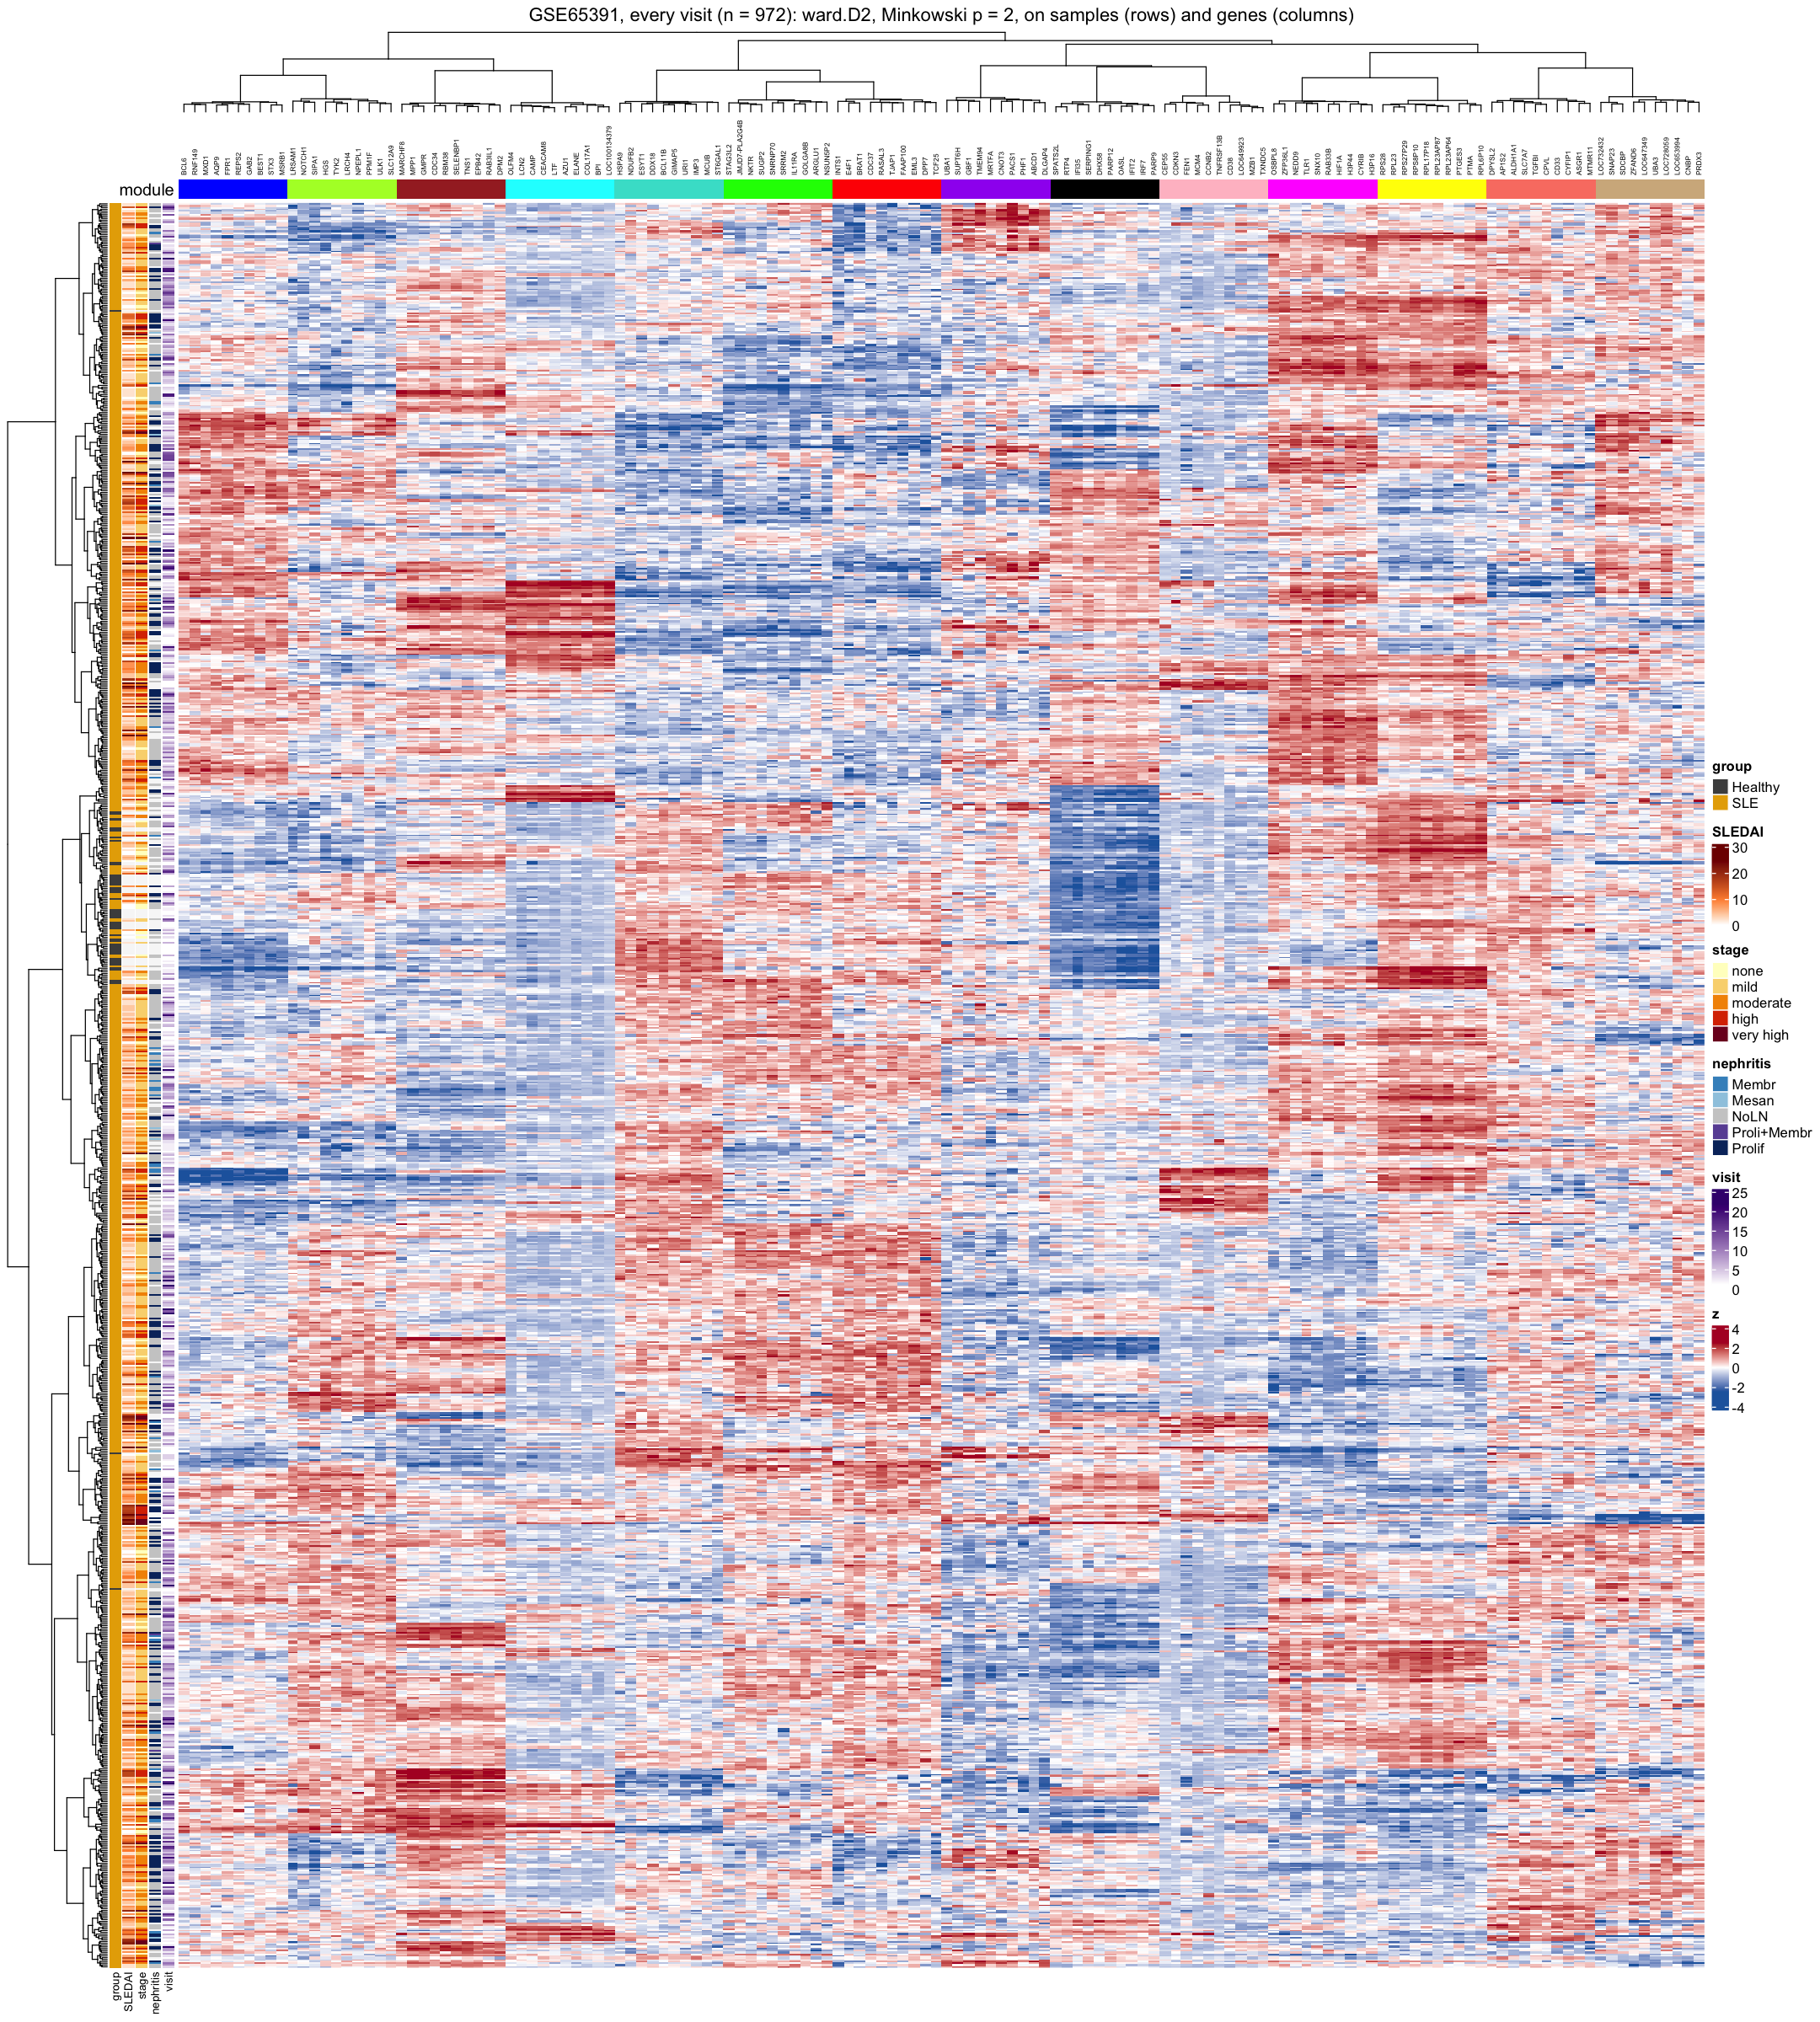

In [2]:
left <- rowAnnotation(
  group = m$disease, SLEDAI = m$sledai, stage = m$stage, nephritis = m$nephritis_class, visit = m$visit,
  na_col = "grey97",
  col = list(group = c(Healthy = "grey30", SLE = "#E6AB02"),
             SLEDAI = colorRamp2(c(0, 10, 25), c("white", "#FD8D3C", "#7F0000")),
             stage = setNames(hcl.colors(5, "YlOrRd", rev = TRUE), levels(m$stage)),
             nephritis = c(NoLN = "grey80", Mesan = "#9ecae1", Membr = "#4292c6", Prolif = "#08306b", "Proli+Membr" = "#6a51a3"),
             visit = colorRamp2(c(1, 22), c("white", "#3f007d"))),
  annotation_name_gp = gpar(fontsize = 8), simple_anno_size = unit(3, "mm"))
options(repr.plot.width = 18, repr.plot.height = 20)
figure <- function() {
  Heatmap(Xc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hc_samples, cluster_columns = hc_genes,
          row_dend_side = "left", column_dend_side = "top",
          row_dend_width = unit(25, "mm"), column_dend_height = unit(20, "mm"),
          show_row_names = FALSE, column_names_side = "top", column_names_gp = gpar(fontsize = 5),
          top_annotation = HeatmapAnnotation(module = gene_module, col = list(module = setNames(unique(gene_module), unique(gene_module))),
                                             show_legend = FALSE, annotation_name_side = "left"),
          left_annotation = left, use_raster = TRUE,
          column_title = "GSE65391, every visit (n = 972): ward.D2, Minkowski p = 2, on samples (rows) and genes (columns)")
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "07c_GSE65391_RNA_array_heatmap_all_visits_clustered_1.png"), width = 18, height = 20, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `rowAnnotation(...)` adds the strips on the left: healthy or SLE, SLEDAI, stage, nephritis class and visit
  number (see notebook 07 for strips and colours).
- `Heatmap(...)` as in notebook 07, with `cluster_rows = hc_samples`: the samples are ordered by their Ward
  tree, drawn whole on the left.
- `show_row_names = FALSE`: 972 sample identifiers cannot be read at this size, so they are not shown.
- `use_raster = TRUE` draws the rows as an image, which keeps the file small.
- The figure loop is explained in notebook 04.